# GPU Model Classification Analysis

## Data Analysis and Feature Engineering

In [0]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.ml.stat import Correlation
from pyspark.sql.functions import col, min, max
from pyspark.ml.feature import VectorAssembler, StringIndexer


In [0]:
gpu = spark.read.csv("/Volumes/pyspark-data/default/pyspark-vol/resources.csv", header=True)

In [0]:
gpu.printSchema()

root
 |-- job_name: string (nullable = true)
 |-- organization: string (nullable = true)
 |-- gpu_model: string (nullable = true)
 |-- cpu_request: string (nullable = true)
 |-- gpu_request: string (nullable = true)
 |-- worker_num: string (nullable = true)
 |-- submit_time: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- job_type: string (nullable = true)



In [0]:
gpu.show()

+--------+------------+--------------+-----------+-----------+----------+-----------+----------+--------+
|job_name|organization|     gpu_model|cpu_request|gpu_request|worker_num|submit_time|  duration|job_type|
+--------+------------+--------------+-----------+-----------+----------+-----------+----------+--------+
|  239255|          13|           A10|       20.0|        1.0|         1|        0.0| 2764799.0|      HP|
|  253689|          13|           A10|        8.0|        1.0|         1|        0.0|15897599.0|      HP|
|  236907|          13|           A10|        8.0|        1.0|         1|        0.0| 9857174.0|      HP|
|  253671|          13|  GPU-series-1|        4.0|        1.0|         1|        0.0| 1727999.0|      HP|
|  236901|          13|           A10|        8.0|        1.0|         1|        0.0|15897599.0|      HP|
|  253670|          13|  GPU-series-1|        4.0|        1.0|         1|        0.0| 1727999.0|      HP|
|  253629|          34|           A10|       1

In [0]:
# Drop rows with missing values
print(f'Number of data points before dropping missing values: {gpu.count()}')
gpu = gpu.na.drop()
print(f'Number of data points after dropping missing values: {gpu.count()}')

Number of data points before dropping missing values: 466867
Number of data points after dropping missing values: 466867


In [0]:
# String Indexer converts string labels to numerical labels
indexer = StringIndexer(
    inputCols=["gpu_model", "job_type"],
    outputCols=["gpu_model_indexed", "job_type_indexed"],
).fit(gpu)
gpu_indexed = indexer.transform(gpu)

# Drop String columns now
gpu_indexed = gpu_indexed.drop("gpu_model", "job_type")

In [0]:
# Convert numerical values in string format to float
int_cols = ["cpu_request", "gpu_request", "worker_num", "duration", "submit_time", "organization"]
for c in int_cols:
    gpu_indexed = gpu_indexed.withColumn(c, col(c).cast("float"))

In [0]:
gpu_indexed.printSchema()

root
 |-- job_name: string (nullable = true)
 |-- organization: float (nullable = true)
 |-- cpu_request: float (nullable = true)
 |-- gpu_request: float (nullable = true)
 |-- worker_num: float (nullable = true)
 |-- submit_time: float (nullable = true)
 |-- duration: float (nullable = true)
 |-- gpu_model_indexed: double (nullable = false)
 |-- job_type_indexed: double (nullable = false)



In [0]:
import pandas as pd

gpu_pd = gpu_indexed.toPandas()
gpu_pd.head()

,job_name,organization,cpu_request,gpu_request,worker_num,submit_time,duration,gpu_model_indexed,job_type_indexed
0,239255,13.0,20.0,1.0,1.0,0.0,2764799.0,0.0,0.0
1,253689,13.0,8.0,1.0,1.0,0.0,15897599.0,0.0,0.0
2,236907,13.0,8.0,1.0,1.0,0.0,9857174.0,0.0,0.0
3,253671,13.0,4.0,1.0,1.0,0.0,1727999.0,3.0,0.0
4,236901,13.0,8.0,1.0,1.0,0.0,15897599.0,0.0,0.0


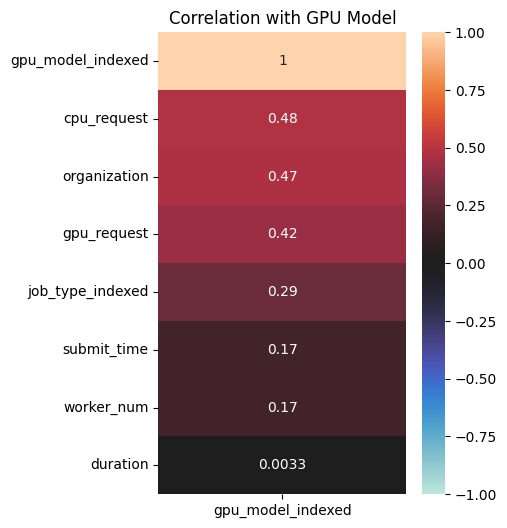

In [0]:
# Visualize the correlation between different features with respect to the gpu_model
target_corr = gpu_pd.corr()[["gpu_model_indexed"]].drop(['job_name']).sort_values(
    by="gpu_model_indexed", ascending=False
)

# Plotting
plt.figure(figsize=(4, 6))
sns.heatmap(target_corr, annot=True, cmap="icefire", vmin=-1, vmax=1)
plt.title("Correlation with GPU Model")
plt.show()

In [0]:
gpu_indexed.show()

+--------+------------+-----------+-----------+----------+-----------+-----------+-----------------+----------------+
|job_name|organization|cpu_request|gpu_request|worker_num|submit_time|   duration|gpu_model_indexed|job_type_indexed|
+--------+------------+-----------+-----------+----------+-----------+-----------+-----------------+----------------+
|  239255|        13.0|       20.0|        1.0|       1.0|        0.0|  2764799.0|              0.0|             0.0|
|  253689|        13.0|        8.0|        1.0|       1.0|        0.0|1.5897599E7|              0.0|             0.0|
|  236907|        13.0|        8.0|        1.0|       1.0|        0.0|  9857174.0|              0.0|             0.0|
|  253671|        13.0|        4.0|        1.0|       1.0|        0.0|  1727999.0|              3.0|             0.0|
|  236901|        13.0|        8.0|        1.0|       1.0|        0.0|1.5897599E7|              0.0|             0.0|
|  253670|        13.0|        4.0|        1.0|       1.

Hence, <br>
Input features: <em>**cpu_request, organization, gpu_request, job_type_indexed, submit_time, worker_num**</em> <br>
Target output: <em>**gpu_model_indexed**</em> 
<br>
We ignore <em>duration</em> due to its low correlation with the target column and <em>job_name</em> since it's unique for each row

## Train and Test Split

In [0]:
# We don't need to use the gpu_indexed df because the indexing will be taken care by the Pipeline
gpu.show()

+--------+------------+--------------+-----------+-----------+----------+-----------+----------+--------+
|job_name|organization|     gpu_model|cpu_request|gpu_request|worker_num|submit_time|  duration|job_type|
+--------+------------+--------------+-----------+-----------+----------+-----------+----------+--------+
|  239255|          13|           A10|       20.0|        1.0|         1|        0.0| 2764799.0|      HP|
|  253689|          13|           A10|        8.0|        1.0|         1|        0.0|15897599.0|      HP|
|  236907|          13|           A10|        8.0|        1.0|         1|        0.0| 9857174.0|      HP|
|  253671|          13|  GPU-series-1|        4.0|        1.0|         1|        0.0| 1727999.0|      HP|
|  236901|          13|           A10|        8.0|        1.0|         1|        0.0|15897599.0|      HP|
|  253670|          13|  GPU-series-1|        4.0|        1.0|         1|        0.0| 1727999.0|      HP|
|  253629|          34|           A10|       1

In [0]:
# Convert numerical values in string format to float
int_cols = ["cpu_request", "gpu_request", "worker_num", "duration", "submit_time", "organization"]
for c in int_cols:
    gpu = gpu.withColumn(c, col(c).cast("float"))

gpu.printSchema()

root
 |-- job_name: string (nullable = true)
 |-- organization: float (nullable = true)
 |-- gpu_model: string (nullable = true)
 |-- cpu_request: float (nullable = true)
 |-- gpu_request: float (nullable = true)
 |-- worker_num: float (nullable = true)
 |-- submit_time: float (nullable = true)
 |-- duration: float (nullable = true)
 |-- job_type: string (nullable = true)



In [0]:
# Only select the target column and the features
data = gpu.select(
    "gpu_model", # target column
    "cpu_request",
    "organization",
    "gpu_request",
    "job_type",
    "submit_time",
    "worker_num",
    "job_name" # need it temporarily to perform quick test set generation using anti-join
)
data.show()

+--------------+-----------+------------+-----------+--------+-----------+----------+--------+
|     gpu_model|cpu_request|organization|gpu_request|job_type|submit_time|worker_num|job_name|
+--------------+-----------+------------+-----------+--------+-----------+----------+--------+
|           A10|       20.0|        13.0|        1.0|      HP|        0.0|       1.0|  239255|
|           A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|  253689|
|           A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|  236907|
|  GPU-series-1|        4.0|        13.0|        1.0|      HP|        0.0|       1.0|  253671|
|           A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|  236901|
|  GPU-series-1|        4.0|        13.0|        1.0|      HP|        0.0|       1.0|  253670|
|           A10|       16.0|        34.0|        1.0|      HP|        0.0|       1.0|  253629|
|           A10|        8.0|        13.0|        1

In [0]:
data.groupBy("gpu_model").count().show()

+--------------+------+
|     gpu_model| count|
+--------------+------+
|  GPU-series-1| 18911|
|  GPU-series-2| 30397|
|          H800| 11097|
|           A10|228643|
|A100-SXM4-80GB|169020|
|A800-SXM4-80GB|  8799|
+--------------+------+



Due to uneven distribution of classes, Class Weighting needs to be implemented and when splitting data into train and test, we need to stratify it

In [0]:
# Get the different target classes
fractions = [row[0] for row in data.select("gpu_model").distinct().collect()]

# Assign the train split to 80% for each class
fractions_dict = {val: 0.8 for val in fractions}

print(fractions_dict)

{'GPU-series-1': 0.8, 'GPU-series-2': 0.8, 'H800': 0.8, 'A10': 0.8, 'A100-SXM4-80GB': 0.8, 'A800-SXM4-80GB': 0.8}


In [0]:
# Sample data points from the main dataset using the fractions_dict
train_data = data.sampleBy('gpu_model', fractions=fractions_dict, seed=42)
print(f'Training datset size: {train_data.count()}')

test_data = data.join(train_data, on='job_name', how='left_anti')
print(f'Test dataset size: {test_data.count()}')

# No need for job_name anymore
train_data = train_data.drop('job_name')
test_data = test_data.drop('job_name')

Training datset size: 373486
Test dataset size: 93381


Weights need to be applied only to training dataset and not test dataset to prevent data leakage

In [0]:
train_data.groupBy("gpu_model").count().show()

+--------------+------+
|     gpu_model| count|
+--------------+------+
|  GPU-series-1| 15146|
|  GPU-series-2| 24419|
|          H800|  8872|
|           A10|183044|
|A100-SXM4-80GB|134963|
|A800-SXM4-80GB|  7042|
+--------------+------+



In [0]:
# Formula: weight = total_rows/(num_classes * class_count)
total_rows = train_data.count()
num_classes = train_data.select("gpu_model").distinct().count()

# Create a new column to calculate the weights of each class
weighted_df = (
    train_data.groupBy("gpu_model")
    .count()
    .withColumn("weight", (total_rows / (num_classes * col("count"))).cast("float"))
)
weighted_df.show()

# Perform a Left Join on the main df to assign weights to each row
train_data = train_data.join(weighted_df, on="gpu_model", how="left").drop('count')


+--------------+------+----------+
|     gpu_model| count|    weight|
+--------------+------+----------+
|  GPU-series-1| 15146|  4.109842|
|  GPU-series-2| 24419| 2.5491488|
|          H800|  8872| 7.0161934|
|           A10|183044| 0.3400694|
|A100-SXM4-80GB|134963|0.46122023|
|A800-SXM4-80GB|  7042|  8.839487|
+--------------+------+----------+



In [0]:
train_data.show()

+------------+-----------+------------+-----------+--------+-----------+----------+---------+
|   gpu_model|cpu_request|organization|gpu_request|job_type|submit_time|worker_num|   weight|
+------------+-----------+------------+-----------+--------+-----------+----------+---------+
|         A10|       20.0|        13.0|        1.0|      HP|        0.0|       1.0|0.3400694|
|         A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|0.3400694|
|GPU-series-1|        4.0|        13.0|        1.0|      HP|        0.0|       1.0| 4.109842|
|         A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|0.3400694|
|GPU-series-1|        4.0|        13.0|        1.0|      HP|        0.0|       1.0| 4.109842|
|         A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|0.3400694|
|         A10|       16.0|        34.0|        1.0|      HP|        0.0|       1.0|0.3400694|
|         A10|        4.0|        13.0|        1.0|      HP|

In [0]:
test_data.show()

+--------------+-----------+------------+-----------+--------+-----------+----------+
|     gpu_model|cpu_request|organization|gpu_request|job_type|submit_time|worker_num|
+--------------+-----------+------------+-----------+--------+-----------+----------+
|           A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|
|           A10|       16.0|        34.0|        1.0|      HP|        0.0|       1.0|
|A800-SXM4-80GB|      112.0|        57.0|        8.0|      HP|        0.0|       1.0|
|           A10|        4.0|        13.0|        1.0|      HP|        0.0|       1.0|
|           A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|
|           A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|
|           A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|
|           A10|        8.0|        13.0|        1.0|      HP|        0.0|       1.0|
|A100-SXM4-80GB|       10.0|         4.0|        1.0| 

## MLlib Pipelines for Classification

In [0]:
from pyspark.ml.pipeline import Pipeline
from pyspark.ml.tuning import ParamGridBuilder
from pyspark.ml.feature import StandardScaler, StringIndexer, VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [0]:
indexer = StringIndexer(
    inputCols=["gpu_model", "job_type"],
    outputCols=["gpu_model_indexed", "job_type_indexed"],
)

assembler = VectorAssembler(
    inputCols=[
        "cpu_request",
        "organization",
        "gpu_request",
        "worker_num",
        "submit_time",
        "job_type_indexed",
    ],
    outputCol="features",
)

scaler = StandardScaler(
    inputCol='features',
    outputCol='features_scaled',
    withStd=True,
    withMean=True
)

evaluator = MulticlassClassificationEvaluator(
    labelCol="gpu_model_indexed", predictionCol="prediction", metricName="f1"
)


### Logistic Regression

In [0]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol='features_scaled', labelCol='gpu_model_indexed', predictionCol='prediction')

# Create the pipeline
lr_pipeline = Pipeline(stages=[indexer, assembler, scaler, lr])

# Fit the pipeline to training documents.
lr_model = lr_pipeline.fit(train_data)

# Make predictions on test documents and print columns of interest.
predictions = lr_model.transform(test_data)
predictions.select("gpu_model", "prediction", "probability")
# Evaluate the model
evaluator.evaluate(predictions)



+--------------+----------+--------------------+
|     gpu_model|prediction|         probability|
+--------------+----------+--------------------+
|           A10|       0.0|[0.90795971669239...|
|           A10|       0.0|[0.51551546672295...|
|A800-SXM4-80GB|       1.0|[1.16838244328130...|
|           A10|       0.0|[0.91775488907429...|
|           A10|       0.0|[0.90795971669239...|
|           A10|       0.0|[0.90795971669239...|
|           A10|       0.0|[0.90795971669239...|
|           A10|       0.0|[0.90795971669239...|
|A100-SXM4-80GB|       0.0|[0.94722927742581...|
|           A10|       0.0|[0.90795971669239...|
+--------------+----------+--------------------+
only showing top 10 rows


0.7652977623191373

### Random Forest Classifier

In [0]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    numTrees=75,
    maxDepth=20,
    featuresCol="features_scaled",
    labelCol="gpu_model_indexed",
    predictionCol="prediction",
)

# Create the pipeline
rf_pipeline = Pipeline(stages=[indexer, assembler, scaler, rf])

rf_model = rf_pipeline.fit(train_data)

predictions = rf_model.transform(test_data)
predictions.select("gpu_model_indexed", "prediction", "probability").show()
# Evaluate the model
evaluator.evaluate(predictions)

+-----------------+----------+--------------------+
|gpu_model_indexed|prediction|         probability|
+-----------------+----------+--------------------+
|              0.0|       0.0|[0.98902864290120...|
|              0.0|       0.0|[0.92347537296191...|
|              5.0|       1.0|[0.0,0.8461903121...|
|              0.0|       0.0|[0.98241110984665...|
|              0.0|       0.0|[0.98902864290120...|
|              0.0|       0.0|[0.98902864290120...|
|              0.0|       0.0|[0.98902864290120...|
|              0.0|       0.0|[0.98902864290120...|
|              1.0|       1.0|[0.01676099087795...|
|              0.0|       0.0|[0.98902864290120...|
|              0.0|       0.0|[0.98902864290120...|
|              1.0|       1.0|[0.0,0.9455570105...|
|              0.0|       0.0|[0.98902864290120...|
|              1.0|       1.0|[0.0,0.8461903121...|
|              0.0|       0.0|[0.98902864290120...|
|              0.0|       0.0|[0.98902864290120...|
|           

0.9229664707712238

In [0]:
# 1. Delete the variables from your local Python memory
try:
    del cv
    del rf_pipeline
    del best_model
    del lr_pipline
except NameError:
    pass

# 2. Force Python to clean up the memory

import gc
gc.collect()

7609